# Clase 8 · Componentes principales

**Módulo 1: Introducción y fundamentos estadísticos** · Diplomado en Ciencia de Datos Aplicada · UTFSM

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/daniopitz/diplomado-cdd/blob/main/08_componentes_principales_colab.ipynb)

Versión para **Google Colab**. Antes de trabajar, guarde su propia copia con `Archivo > Guardar una copia en Drive`.

**Qué hacemos hoy.** Volvemos a los 263 jugadores de béisbol de la clase 7, cuyas 16 variables numéricas se correlacionan en bloques, y les aplicamos el análisis de componentes principales (PCA): calculamos las componentes, vemos cuánta variación explica cada una y de qué está hecha, y dibujamos a los jugadores en el plano de las dos primeras. Después repetimos el cálculo con las flores de iris de la clase 2. Los datos del béisbol son del libro de James, Witten, Hastie y Tibshirani (2013), cuya sección 10.2 (pp. 374 a 385) es la lectura de esta clase.

**La idea de la clase:** muchas variables que se mueven juntas dicen pocas cosas. PCA encuentra cuántas cosas distintas dicen y cuánto pesa cada una, construyendo variables nuevas en vez de elegir entre las originales.

## 1. Preparación

Las bibliotecas de siempre, más tres piezas de **scikit-learn**: `StandardScaler` (la estandarización de la clase 7), `PCA` (el cálculo de hoy) y `load_iris` (las flores de la clase 2).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn: estandarizar, calcular componentes principales y cargar iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris

sns.set_theme(style="whitegrid")
%config InlineBackend.figure_format = "retina"
pd.options.display.float_format = "{:.3f}".format

In [2]:
# Los datos se leen directo desde el repositorio del curso en GitHub
BASE = "https://raw.githubusercontent.com/daniopitz/diplomado-cdd/main/datos/"

## 2. Las 16 variables numéricas del béisbol

**Objetivo:** tener la tabla de la clase 7 con sus nombres en español, solo con las variables numéricas.

Los mismos pasos de la clase 7: se descartan los 59 jugadores sin salario y se traducen los nombres. Esta vez quedan fuera las tres variables categóricas (liga, división y liga de 1987): PCA trabaja con variables numéricas, y una dummy de 0 y 1 no tiene una escala en la que tenga sentido hablar de su variación junto a las demás.

In [3]:
jugadores = pd.read_csv(BASE + "clase07/hitters_islr.csv").dropna(subset=["Salary"])
nombres = {
    "AtBat": "turnos", "Hits": "hits", "HmRun": "jonrones", "Runs": "anotadas", "RBI": "impulsadas",
    "Walks": "bases_bolas", "Years": "temporadas", "CAtBat": "turnos_carrera", "CHits": "hits_carrera",
    "CHmRun": "jonrones_carrera", "CRuns": "anotadas_carrera", "CRBI": "impulsadas_carrera",
    "CWalks": "bases_bolas_carrera", "PutOuts": "outs_defensa", "Assists": "asistencias", "Errors": "errores",
}
X = jugadores.rename(columns=nombres)[list(nombres.values())].astype(float)
salario = jugadores["Salary"]   # miles de dólares en 1987; PCA no lo usa
print("jugadores:", len(X), "| variables:", X.shape[1])
X.head()

jugadores: 263 | variables: 16


,turnos,hits,jonrones,anotadas,impulsadas,bases_bolas,temporadas,turnos_carrera,hits_carrera,jonrones_carrera,anotadas_carrera,impulsadas_carrera,bases_bolas_carrera,outs_defensa,asistencias,errores
1,315.000,81.000,7.000,24.000,38.000,39.000,14.000,3449.000,835.000,69.000,321.000,414.000,375.000,632.000,43.000,10.000
2,479.000,130.000,18.000,66.000,72.000,76.000,3.000,1624.000,457.000,63.000,224.000,266.000,263.000,880.000,82.000,14.000
3,496.000,141.000,20.000,65.000,78.000,37.000,11.000,5628.000,1575.000,225.000,828.000,838.000,354.000,200.000,11.000,3.000
4,321.000,87.000,10.000,39.000,42.000,30.000,2.000,396.000,101.000,12.000,48.000,46.000,33.000,805.000,40.000,4.000
5,594.000,169.000,4.000,74.000,51.000,35.000,11.000,4408.000,1133.000,19.000,501.000,336.000,194.000,282.000,421.000,25.000


**Recordatorio de la clase 7.** Las variables se correlacionan en bloques: las de la carrera entre sí, y las de la temporada 1986 entre sí. El par más extremo son los turnos y los hits de la carrera:

In [4]:
X[["temporadas", "turnos_carrera", "hits_carrera", "anotadas_carrera"]].corr().round(3)

,temporadas,turnos_carrera,hits_carrera,anotadas_carrera
temporadas,1.000,0.916,0.898,0.877
turnos_carrera,0.916,1.000,0.995,0.983
hits_carrera,0.898,0.995,1.000,0.985
anotadas_carrera,0.877,0.983,0.985,1.000


## 3. Dos variables, una sola dirección

**Objetivo:** ver qué hace PCA en el caso más simple, con dos variables que dicen casi lo mismo.

Los turnos y los hits de la carrera tienen correlación 0,995. En un gráfico de dispersión los jugadores se ordenan a lo largo de una diagonal: casi toda la variación ocurre en esa dirección, y casi ninguna en la perpendicular. PCA encuentra esas dos direcciones. Primero se estandarizan las dos variables (media 0 y desviación 1), y luego `PCA().fit()` calcula las componentes.

In [5]:
dos = X[["turnos_carrera", "hits_carrera"]]
Z2 = StandardScaler().fit_transform(dos)   # cada columna con media 0 y desviación 1
pca2 = PCA().fit(Z2)
print("variación explicada por cada componente:", pca2.explained_variance_ratio_.round(3))
print("pesos de cada componente (una fila por componente):")
print(pca2.components_.round(3))

variación explicada por cada componente: [0.998 0.002]
pesos de cada componente (una fila por componente):
[[ 0.707  0.707]
 [ 0.707 -0.707]]


La primera componente explica el 99,8% de la variación y la segunda el 0,2%. Sus pesos son (0,707, 0,707) y (0,707, −0,707): la primera componente es la **suma** de las dos variables estandarizadas (dividida por √2, para que los pesos al cuadrado sumen 1) y la segunda es su **diferencia**. Para estos jugadores, saber la suma es saber casi todo; la diferencia casi no varía.

**En la práctica, una componente es un puntaje ponderado por jugador**, como el puntaje ponderado de la admisión universitaria: cada variable entra con su peso y sale un número por jugador. La cuenta a mano para los tres primeros jugadores da lo mismo que `pca2.transform`:

In [6]:
puntajes2 = pca2.transform(Z2)                      # cada jugador en las dos componentes
w1, w2 = pca2.components_[0]                        # los pesos de la primera componente
a_mano = w1 * Z2[:, 0] + w2 * Z2[:, 1]              # la suma ponderada, jugador por jugador
pd.DataFrame({"z_turnos_carrera": Z2[:3, 0], "z_hits_carrera": Z2[:3, 1],
              "suma ponderada": a_mano[:3], "primera componente (sklearn)": puntajes2[:3, 0]})

,z_turnos_carrera,z_hits_carrera,suma ponderada,primera componente (sklearn)
0,0.347,0.174,0.369,0.369
1,-0.453,-0.410,-0.610,-0.610
2,1.302,1.318,1.852,1.852


**De dónde sale el 99,8%.** La variación de una coordenada se mide con su varianza (clase 2). Las dos variables estandarizadas tienen varianza 1 y 1: la variación total de los datos es 2. Las dos coordenadas nuevas (los puntajes en las dos componentes) reparten esa misma variación total: sus varianzas también suman 2, y la proporción de cada una es lo que scikit-learn llama `explained_variance_ratio_`:

In [7]:
varianzas_originales = Z2.var(axis=0)        # turnos (z) y hits (z): 1 y 1
varianzas_nuevas = puntajes2.var(axis=0)     # 1.ª y 2.ª componente
print("varianzas originales:", varianzas_originales.round(3), "| total:", varianzas_originales.sum().round(3))
print("varianzas nuevas:    ", varianzas_nuevas.round(3), "| total:", varianzas_nuevas.sum().round(3))
print("proporción de cada componente:", (varianzas_nuevas / varianzas_nuevas.sum()).round(4))

varianzas originales: [1. 1.] | total: 2.0
varianzas nuevas:     [1.995 0.005] | total: 2.0
proporción de cada componente: [0.9975 0.0025]


En el gráfico, las flechas son las dos direcciones, con un largo proporcional a la desviación estándar de los datos en cada una:

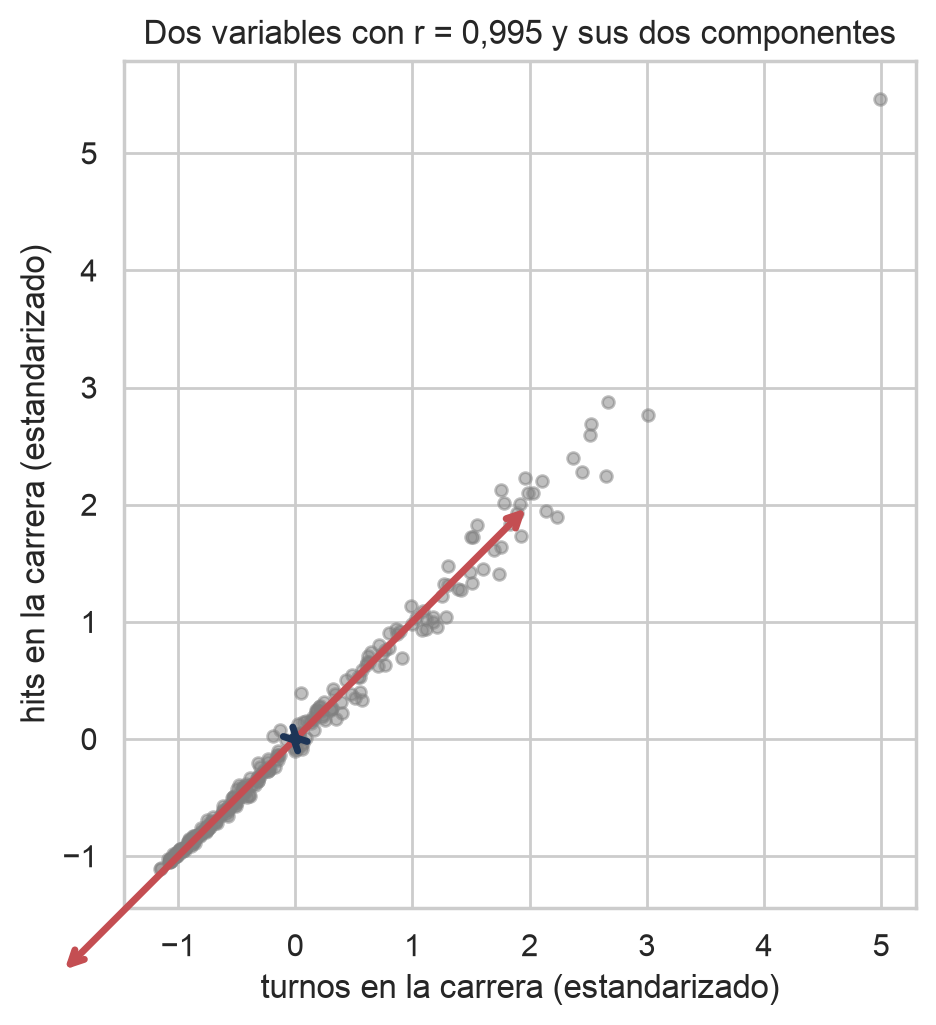

In [8]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(Z2[:, 0], Z2[:, 1], s=18, color="gray", alpha=0.5)
for direccion, desviacion, color in zip(pca2.components_, np.sqrt(pca2.explained_variance_), ["#C44E52", "#1D3557"]):
    largo = 2 * desviacion   # dos desviaciones estándar hacia cada lado
    ax.annotate("", xy=direccion * largo, xytext=-direccion * largo, arrowprops=dict(arrowstyle="<->", color=color, lw=2.5))
ax.set_xlabel("turnos en la carrera (estandarizado)")
ax.set_ylabel("hits en la carrera (estandarizado)")
ax.set_title("Dos variables con r = 0,995 y sus dos componentes")
ax.set_aspect("equal")
plt.show()

## 4. Antes de calcular: estandarizar

**Objetivo:** ver por qué PCA se calcula sobre variables estandarizadas.

PCA busca la dirección en que los datos más varían, y la variación se mide en las unidades de cada variable. Las 16 variables tienen escalas muy distintas:

In [9]:
desviaciones = X.std().sort_values()
desviaciones.round(1)

temporadas               4.800
errores                  6.600
jonrones                 8.800
bases_bolas             21.700
anotadas                25.500
impulsadas              25.900
hits                    45.100
jonrones_carrera        82.200
asistencias            145.100
turnos                 147.300
bases_bolas_carrera    264.100
outs_defensa           279.900
impulsadas_carrera     323.400
anotadas_carrera       331.200
hits_carrera           648.200
turnos_carrera        2286.600
dtype: float64

Los turnos de la carrera tienen una desviación estándar de 2.287 y las temporadas, de 4,8. Sin estandarizar, la primera componente sigue a la variable que más varía en sus unidades:

In [10]:
pca_sin = PCA().fit(X.values)   # las variables en sus unidades originales
print("variación explicada, sin estandarizar:", (pca_sin.explained_variance_ratio_[:4] * 100).round(1), "%")
pesos_sin = pd.Series(pca_sin.components_[0], index=X.columns)
print("la primera componente es casi solo:", pesos_sin.abs().idxmax(), round(pesos_sin.abs().max(), 3))

variación explicada, sin estandarizar: [97.4  1.3  0.5  0.3] %
la primera componente es casi solo: turnos_carrera 0.941


Una sola componente con el 97,4% de la variación, y es casi solo `turnos_carrera`: no dice nada sobre la estructura de los datos, solo que esa variable tiene números grandes. Estandarizando cada variable (media 0, desviación 1, como el puntaje z de la clase 2) todas parten iguales. Se estandariza salvo que las variables compartan unidad (James et al., 2013, p. 381).

In [11]:
escala = StandardScaler().fit(X)
Z = pd.DataFrame(escala.transform(X), columns=X.columns, index=X.index)   # las 16 variables estandarizadas
pca = PCA().fit(Z)
pve = pca.explained_variance_ratio_ * 100   # porcentaje de la variación que explica cada componente
print("variación explicada, estandarizando:", pve[:4].round(1), "%")

variación explicada, estandarizando: [45.3 25.7 10.8  5.4] %


## 5. Cuánta variación explica cada componente

**Objetivo:** decidir con cuántas componentes quedarse.

Con 16 variables hay 16 componentes, ordenadas de la que más variación explica a la que menos. La tabla muestra el porcentaje de cada una y el acumulado:

In [12]:
resumen = pd.DataFrame({
    "variación explicada (%)": pve,
    "acumulada (%)": np.cumsum(pve),
}, index=[f"componente {k}" for k in range(1, 17)])
resumen.round(1)

,variación explicada (%),acumulada (%)
componente 1,45.300,45.300
componente 2,25.700,71.000
componente 3,10.800,81.800
componente 4,5.400,87.200
componente 5,4.400,91.600
componente 6,3.200,94.800
componente 7,1.600,96.400
componente 8,1.200,97.500
componente 9,0.800,98.400
componente 10,0.600,99.000


La primera componente explica el 45,3%; la segunda, el 25,7%; la tercera, el 10,8%. Dos componentes reúnen el 71% y tres, el 82%. El gráfico de barras con la curva acumulada se llama *scree plot*. Para elegir cuántas componentes conservar se mira dónde la curva deja de caer (el codo); no hay una regla objetiva, depende del uso (James et al., 2013, p. 384).

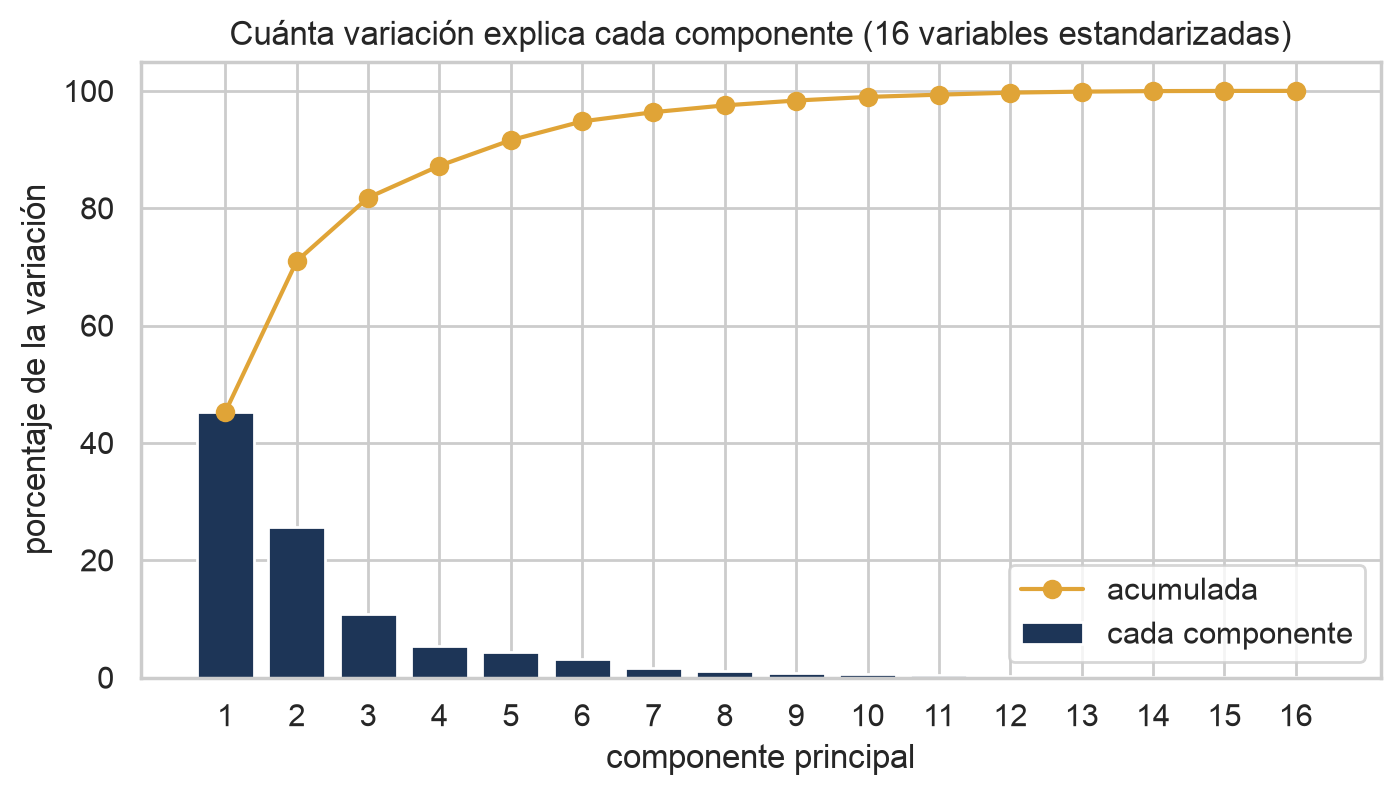

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
k = np.arange(1, 17)
ax.bar(k, pve, color="#1D3557", label="cada componente")
ax.plot(k, np.cumsum(pve), color="#E0A437", marker="o", label="acumulada")
ax.set_xticks(k)
ax.set_xlabel("componente principal")
ax.set_ylabel("porcentaje de la variación")
ax.set_title("Cuánta variación explica cada componente (16 variables estandarizadas)")
ax.legend()
plt.show()

## 6. De qué está hecha cada componente: los pesos

**Objetivo:** leer las dos primeras componentes.

Cada componente es una suma ponderada de las 16 variables estandarizadas, y `pca.components_` guarda los pesos (una fila por componente, una columna por variable). El signo de una componente es arbitrario: cambiarlo a toda la fila no cambia nada (James et al., 2013, p. 382). Aquí se fija para que la primera componente tenga pesos positivos y la segunda tenga positivo el peso de `turnos`, que es como se leen más fácil.

In [14]:
cargas = pd.DataFrame(pca.components_[:3].T, index=X.columns, columns=["PC1", "PC2", "PC3"])
signo = np.array([1 if cargas["PC1"].sum() > 0 else -1,
                  1 if cargas.loc["turnos", "PC2"] > 0 else -1,
                  1])
cargas = cargas * signo
cargas.round(2)

,PC1,PC2,PC3
turnos,0.200,0.390,0.070
hits,0.190,0.380,0.050
jonrones,0.200,0.240,-0.340
anotadas,0.200,0.380,-0.060
impulsadas,0.230,0.320,-0.170
bases_bolas,0.210,0.240,-0.070
temporadas,0.290,-0.260,0.100
turnos_carrera,0.330,-0.190,0.130
hits_carrera,0.330,-0.180,0.120
jonrones_carrera,0.320,-0.120,-0.120


**Primera componente (45%):** las siete variables de la carrera pesan casi lo mismo (0,29 a 0,34), las seis de la temporada 1986 la mitad (0,19 a 0,23) y las tres de defensa casi nada. Mide cuánta carrera lleva el jugador.

**Segunda componente (26%):** la temporada 1986 pesa positivo (0,24 a 0,39) y la carrera negativo (−0,12 a −0,26). Separa a quien rindió este año más de lo que dice su carrera de quien rindió menos.

**Tercera componente (11%):** casi solo asistencias (0,65) y errores (0,57): la defensa, que no entraba en las dos primeras.

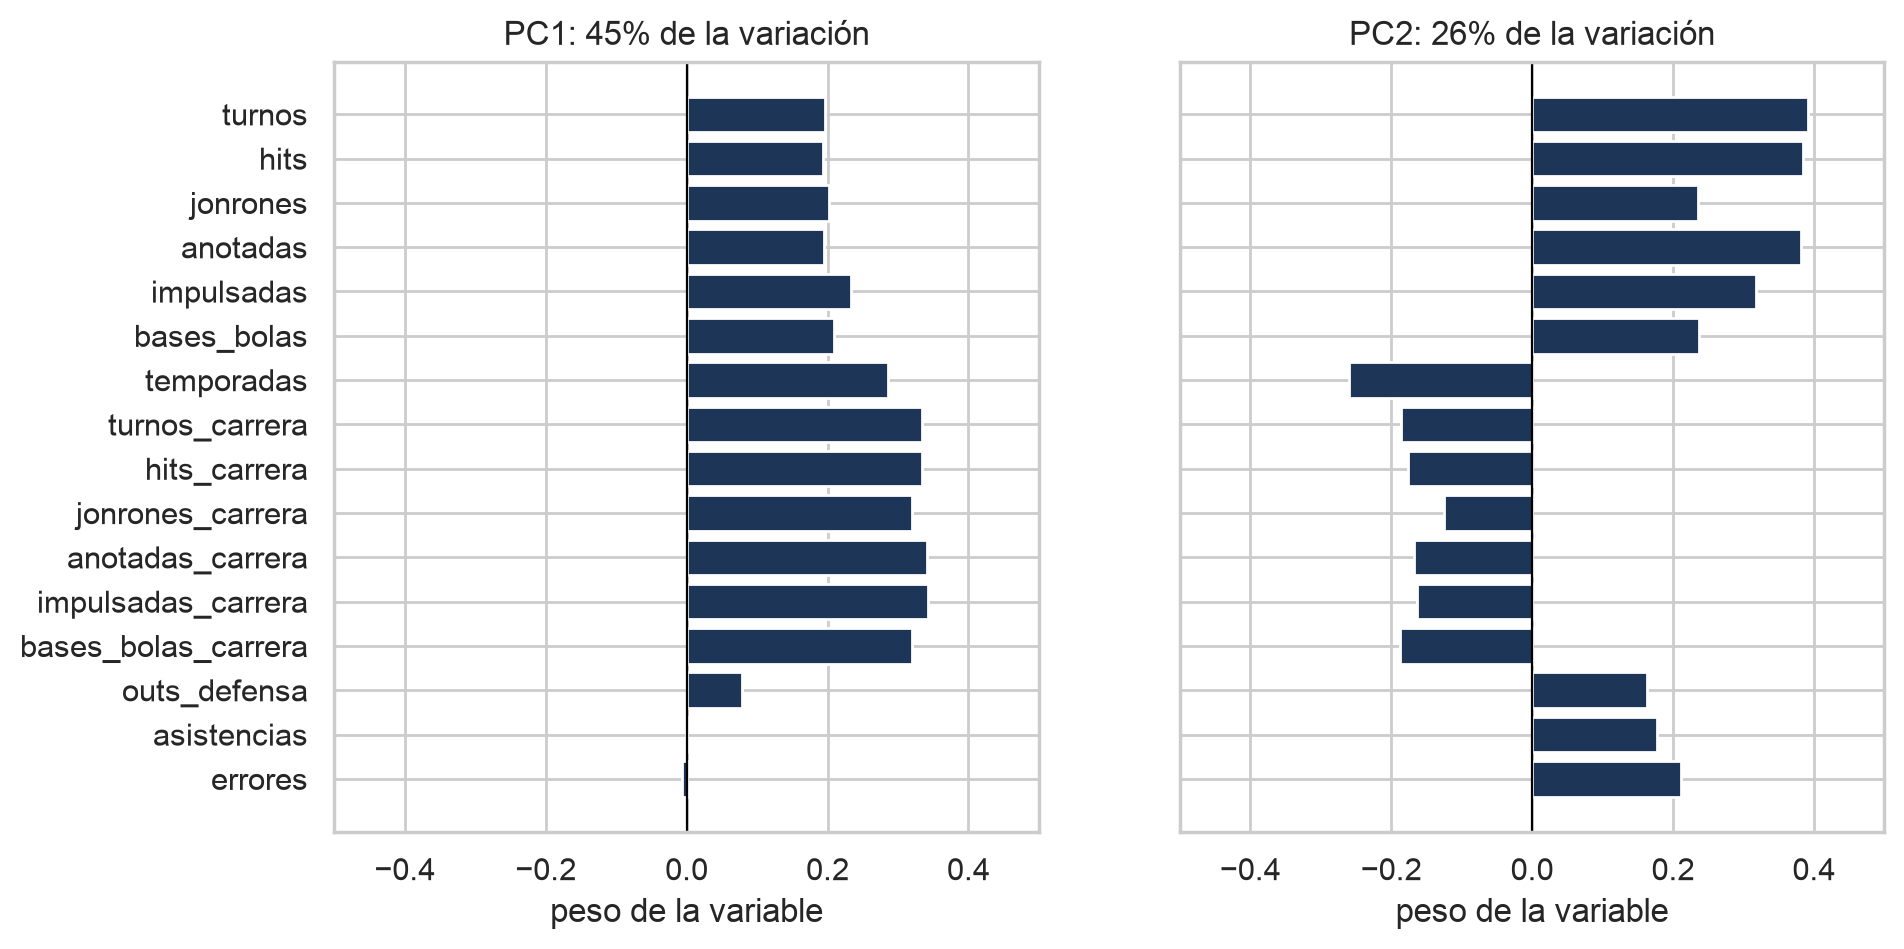

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
for ax, pc in zip(axes, ["PC1", "PC2"]):
    ax.barh(cargas.index, cargas[pc], color="#1D3557")
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlim(-0.5, 0.5)
    ax.set_title(f"{pc}: {pve[int(pc[-1]) - 1]:.0f}% de la variación")
    ax.set_xlabel("peso de la variable")
axes[0].invert_yaxis()
plt.show()

## 7. Los jugadores en el plano de las dos componentes

**Objetivo:** usar las componentes como variables nuevas.

`pca.transform(Z)` calcula, para cada jugador, su valor en cada componente (los *puntajes*). Con las dos primeras se puede dibujar a los 263 jugadores en un solo gráfico, en vez de los 120 gráficos de dispersión que permiten 16 variables. El color es el salario, que PCA no usó:

In [16]:
puntajes = pca.transform(Z) * np.append(signo, np.ones(13))   # mismo signo que las cargas
plano = pd.DataFrame({"PC1": puntajes[:, 0], "PC2": puntajes[:, 1], "salario": salario.values})
plano.head()

,PC1,PC2,salario
0,0.135,-1.648,475.000
1,0.333,2.337,480.000
2,3.552,-0.646,500.000
3,-2.491,0.336,91.500
4,0.965,1.520,750.000


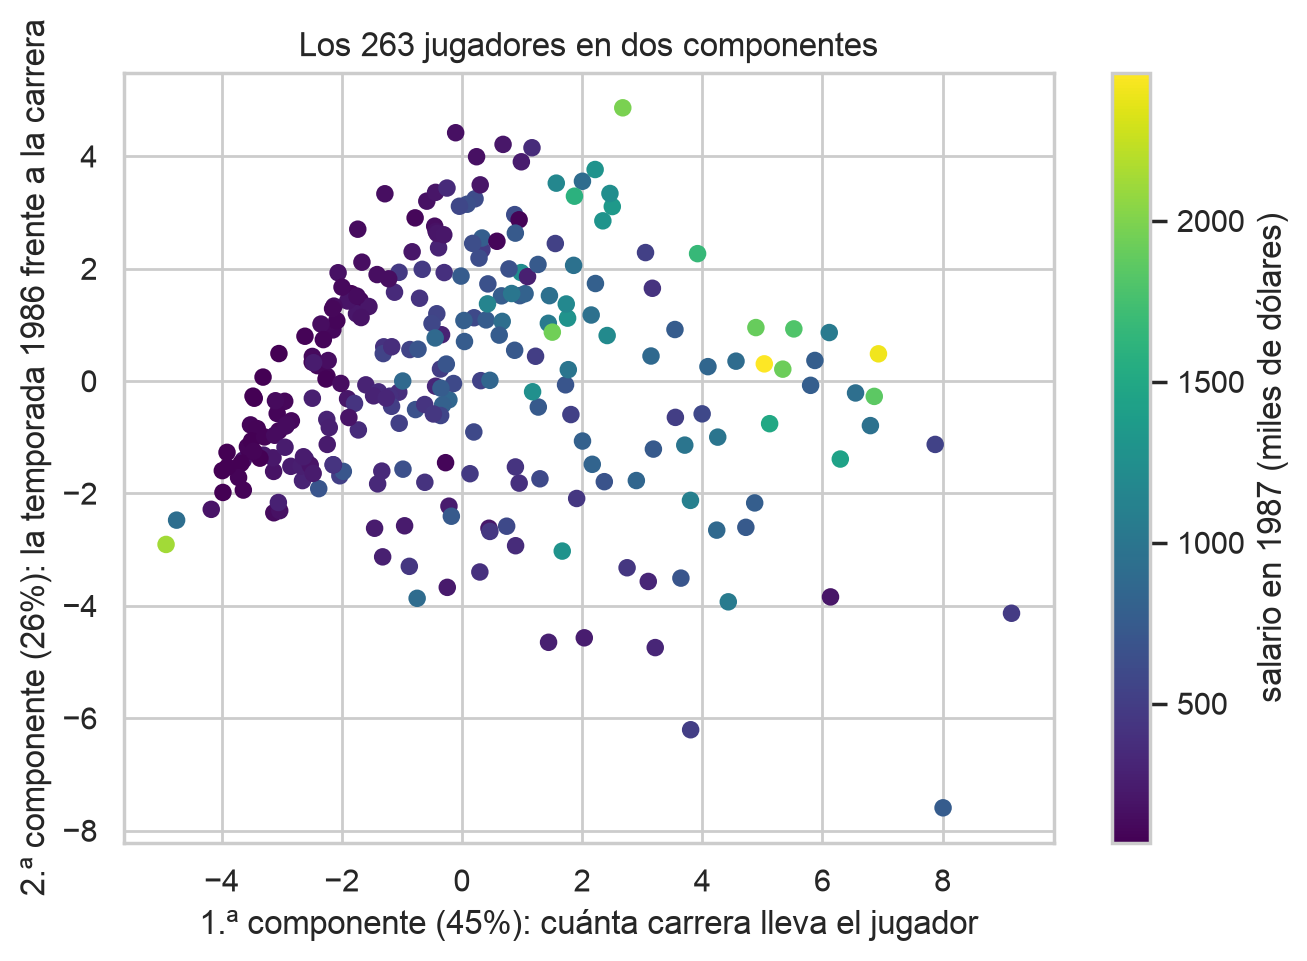

In [17]:
fig, ax = plt.subplots(figsize=(7.5, 5))
puntos = ax.scatter(plano["PC1"], plano["PC2"], c=plano["salario"], cmap="viridis", s=28)
fig.colorbar(puntos, ax=ax, label="salario en 1987 (miles de dólares)")
ax.set_xlabel(f"1.ª componente ({pve[0]:.0f}%): cuánta carrera lleva el jugador")
ax.set_ylabel(f"2.ª componente ({pve[1]:.0f}%): la temporada 1986 frente a la carrera")
ax.set_title("Los 263 jugadores en dos componentes")
plt.show()

In [18]:
print("correlación del salario con la 1.ª componente:", round(plano["PC1"].corr(plano["salario"]), 2))
print("correlación del salario con la 2.ª componente:", round(plano["PC2"].corr(plano["salario"]), 2))

correlación del salario con la 1.ª componente: 0.64
correlación del salario con la 2.ª componente: 0.11


El salario crece hacia la derecha (correlación 0,64 con la primera componente) y casi nada hacia arriba (0,11 con la segunda): la carrera pesa en el salario y la última temporada, poco. Es una lectura que en la clase 7 exigía mirar 16 coeficientes; aquí está en dos ejes. Con las componentes como variables nuevas se puede además ajustar una regresión del salario sobre dos o tres de ellas (regresión sobre componentes principales; James et al., 2013, sección 6.3.1).

## 8. El mismo cálculo con las flores de la clase 2

**Objetivo:** repetir los cinco pasos con otros datos.

Las 150 flores de iris tienen cuatro medidas (largo y ancho del sépalo, largo y ancho del pétalo) y una especie que PCA no conoce.

In [19]:
iris = load_iris()
flores = pd.DataFrame(iris.data, columns=["largo_sepalo", "ancho_sepalo", "largo_petalo", "ancho_petalo"])
Zi = StandardScaler().fit_transform(flores)                       # 1. estandarizar
pca_iris = PCA().fit(Zi)                                          # 2. calcular las componentes
pve_iris = pca_iris.explained_variance_ratio_ * 100               # 3. cuánto explica cada una
cargas_iris = pd.DataFrame(pca_iris.components_[:2].T, index=flores.columns, columns=["PC1", "PC2"])   # 4. los pesos
puntajes_iris = pca_iris.transform(Zi)                            # 5. cada flor en las componentes
print("variación explicada:", pve_iris.round(1), "%")
cargas_iris.round(2)

variación explicada: [73.  22.9  3.7  0.5] %


,PC1,PC2
largo_sepalo,0.520,0.380
ancho_sepalo,-0.270,0.920
largo_petalo,0.580,0.020
ancho_petalo,0.560,0.070


Dos componentes reúnen el 96% de la variación. La primera (73%) pesa casi igual el largo y el ancho del pétalo y el largo del sépalo: el tamaño de la flor. La segunda (23%) es casi solo el ancho del sépalo. (Si en su computador los signos salen invertidos, la lectura es la misma.) Dibujando las flores por especie:

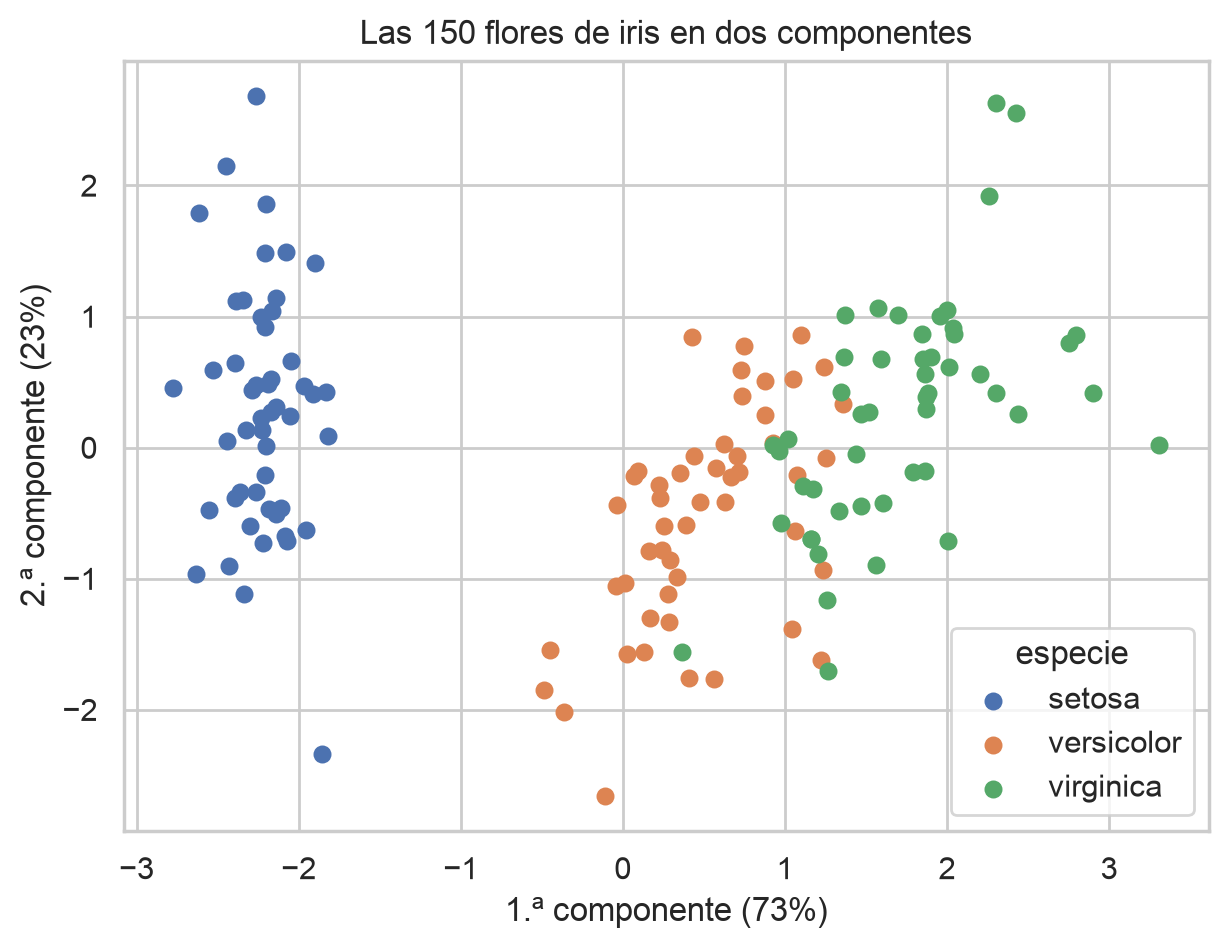

In [20]:
fig, ax = plt.subplots(figsize=(7, 5))
for k, especie in enumerate(iris.target_names):
    m = iris.target == k
    ax.scatter(puntajes_iris[m, 0], puntajes_iris[m, 1], s=30, label=especie)
ax.set_xlabel(f"1.ª componente ({pve_iris[0]:.0f}%)")
ax.set_ylabel(f"2.ª componente ({pve_iris[1]:.0f}%)")
ax.set_title("Las 150 flores de iris en dos componentes")
ax.legend(title="especie")
plt.show()

PCA no conoce la especie y aun así las tres quedan separadas a lo largo de la primera componente: la variación más grande de estos datos es la diferencia de tamaño entre especies.

## 9. Cuándo conviene y cuándo no

- **Conviene** con muchas variables numéricas que se correlacionan en bloques, para mirarlas en un plano o para entregarle a un modelo menos entradas.
- **No aporta** si las variables son pocas y distintas entre sí: no hay nada que resumir.
- Las **variables categóricas** (dummies) no entran bien en el cálculo; se dejan fuera o se tratan aparte.
- Las componentes **no siempre tienen una lectura clara**. Aquí sí, pero no está garantizado.
- Es **no supervisado**: la dirección de más variación no es necesariamente la que mejor predice la respuesta. Ridge y Lasso eligen mirando Y; PCA no la mira.

### Ejercicio

1. Con la tabla `resumen` de la sección 5, ¿cuántas componentes hacen falta para superar el 90% de la variación de las 16 variables?
2. Repita los cinco pasos solo con las seis variables de la temporada 1986 (`turnos`, `hits`, `jonrones`, `anotadas`, `impulsadas`, `bases_bolas`). ¿Qué porcentaje explica la primera componente? ¿Qué variable pesa distinto de las demás en la segunda?

In [21]:
# Ejercicio 1

# Ejercicio 2


---

**Cierre del módulo.** Este es el último notebook del módulo 1. PCA vuelve, junto con clustering, en el módulo 3 (Machine Learning para la Toma de Decisiones). El informe escrito de avance se entrega el viernes 25 de septiembre por el Aula.